In [165]:
!pip install scikit-learn pandas numpy nltk matplotlib wordcloud gensim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
import re
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.decomposition import TruncatedSVD
from nltk.tokenize import RegexpTokenizer

nltk.download('stopwords', quiet=True)

True

Загрузка и первичный анализ данных

In [166]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [167]:
url = '/content/drive/MyDrive/AI/Tweets.csv'

In [168]:
df = pd.read_csv(url)

In [169]:
df.shape

(27481, 4)

In [170]:
df.columns.tolist()

['textID', 'text', 'selected_text', 'sentiment']

In [171]:
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [172]:
df.isnull().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0


In [173]:
df = df.dropna(subset=['text', 'sentiment'])

In [174]:
df.shape

(27480, 4)

Распределение длины твитов

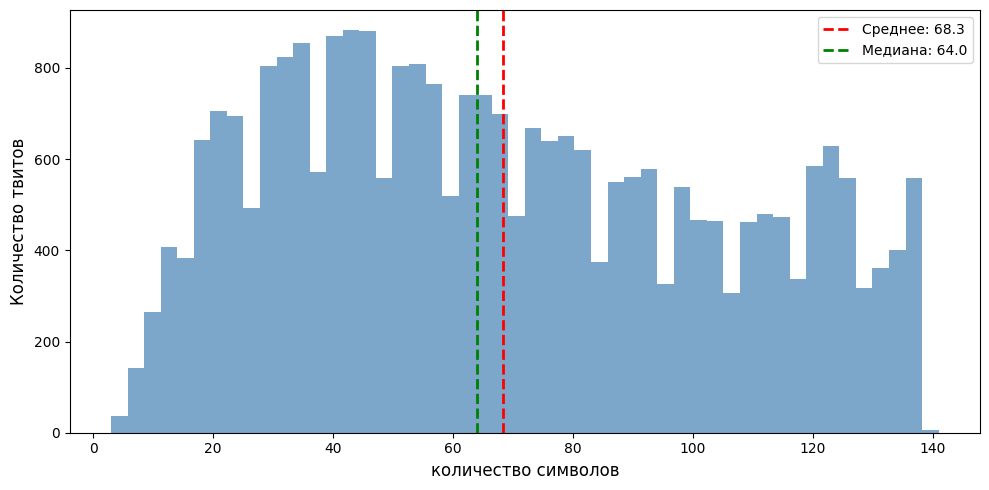

In [175]:
df['text_length'] = df['text'].astype(str).apply(len)

plt.figure(figsize=(10, 5))
plt.hist(df['text_length'], bins=50, alpha=0.7, color='steelblue')
plt.axvline(df['text_length'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Среднее: {df["text_length"].mean():.1f}')
plt.axvline(df['text_length'].median(), color='green', linestyle='dashed', linewidth=2, label=f'Медиана: {df["text_length"].median():.1f}')
plt.xlabel('количество символов', fontsize=12)
plt.ylabel('Количество твитов', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

Облака слов по классам

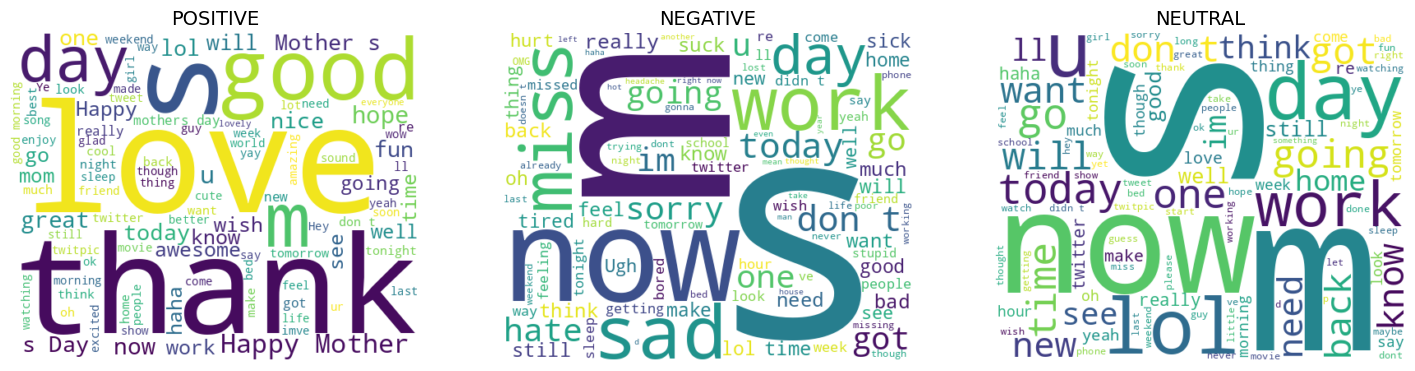

In [176]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, sentiment in enumerate(['positive', 'negative', 'neutral']):
    sentiment_text = ' '.join(df[df['sentiment'] == sentiment]['text'].astype(str).tolist())
    if sentiment_text:
        wordcloud = WordCloud(width=500, height=400, background_color='white', max_words=100).generate(sentiment_text)
        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].axis('off')
        axes[idx].set_title(f'{sentiment.upper()}', fontsize=14)

Очистка текста

In [177]:
def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [178]:
df['clean_text'] = df['text'].apply(clean_text)

tokenizer = RegexpTokenizer(r'\w+')
df['tokens'] = df['clean_text'].apply(tokenizer.tokenize)

df = df[df['clean_text'] != '']
df = df[df['tokens'].apply(len) > 0]

после очистки

In [179]:
df.shape

(27476, 7)

было

In [180]:
df['text'].iloc[24]

'SEe waT I Mean bOuT FoLL0w fRiiDaYs... It`S cALLed LoSe f0LloWeRs FridAy... smH'

стало

In [181]:
df['clean_text'].iloc[24]

'see wat i mean bout follw friidays its called lose fllowers friday smh'

Подготовка данных для обучения

In [182]:
sentiment_map = {'positive': 0, 'negative': 1, 'neutral': 2}
df['label'] = df['sentiment'].map(sentiment_map)

In [183]:
X = df['clean_text'].tolist()
y = df['label'].tolist()

In [184]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

TF-IDF векторизация

In [185]:
vectorizer = TfidfVectorizer( max_features=5000, stop_words='english')

In [186]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Топ-20 слов

In [187]:
feature_names = vectorizer.get_feature_names_out()
tfidf_scores = X_train_tfidf.sum(axis=0).A1
top_indices = tfidf_scores.argsort()[-20:][::-1]
for i, idx in enumerate(top_indices):
    print(f"{i+1:2d}. {feature_names[idx]} (score: {tfidf_scores[idx]:.4f})")

 1. im (score: 526.9561)
 2. day (score: 431.6764)
 3. just (score: 402.2273)
 4. good (score: 338.3978)
 5. like (score: 287.0115)
 6. work (score: 281.4203)
 7. dont (score: 265.9980)
 8. love (score: 261.7476)
 9. happy (score: 252.1181)
10. going (score: 247.4237)
11. today (score: 241.7434)
12. got (score: 231.8562)
13. know (score: 230.5269)
14. time (score: 223.4496)
15. lol (score: 220.6041)
16. really (score: 215.2109)
17. mothers (score: 206.3852)
18. thanks (score: 204.4970)
19. want (score: 187.8627)
20. night (score: 185.6828)


Обучение и сравнение моделей

In [188]:
models = {
    'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
    'SVM': SVC(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Naive Bayes': MultinomialNB()
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        'Модель': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })

    print(f" Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f" Precision: {prec:.4f}")
    print(f" Recall:    {rec:.4f}")
    print(f" F1-score:  {f1:.4f}")
    print(f" Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['positive', 'negative', 'neutral']))

 Accuracy:  0.6881 (68.81%)
 Precision: 0.6889
 Recall:    0.6881
 F1-score:  0.6885
 Classification Report:
              precision    recall  f1-score   support

    positive       0.75      0.73      0.74      1717
    negative       0.66      0.67      0.67      1556
     neutral       0.66      0.67      0.66      2223

    accuracy                           0.69      5496
   macro avg       0.69      0.69      0.69      5496
weighted avg       0.69      0.69      0.69      5496

 Accuracy:  0.6941 (69.41%)
 Precision: 0.6998
 Recall:    0.6941
 F1-score:  0.6945
 Classification Report:
              precision    recall  f1-score   support

    positive       0.77      0.72      0.74      1717
    negative       0.71      0.62      0.66      1556
     neutral       0.64      0.73      0.68      2223

    accuracy                           0.69      5496
   macro avg       0.71      0.69      0.69      5496
weighted avg       0.70      0.69      0.69      5496

 Accuracy:  0.6992 (

In [189]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-score', ascending=False)
best_model_name = results_df.iloc[0]['Модель']
best_f1 = results_df.iloc[0]['F1-score']

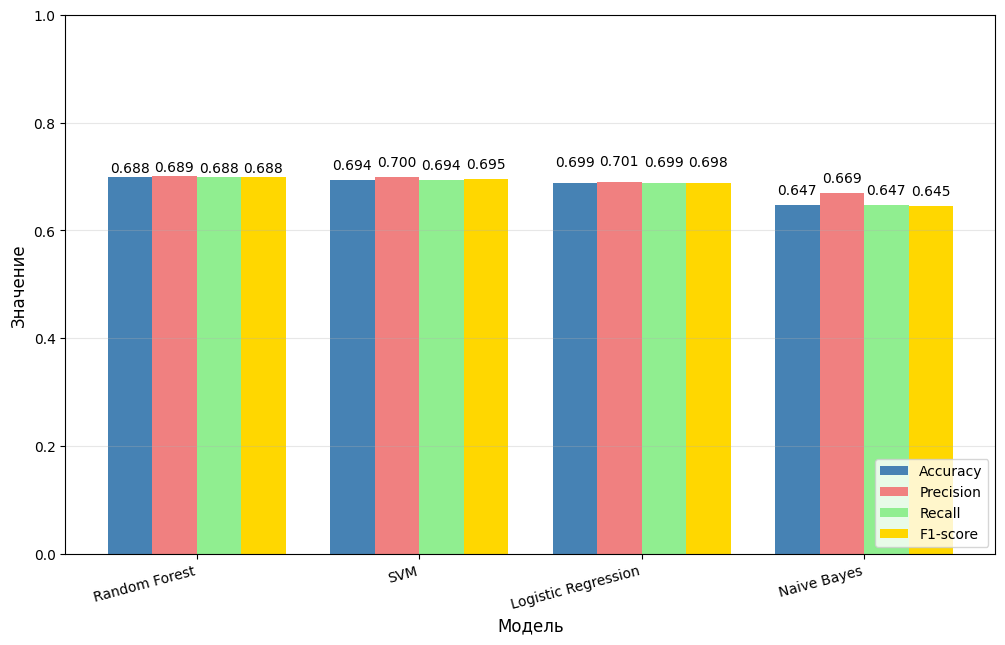

In [190]:
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(results_df['Модель']))
width = 0.2

ax.bar(x - 1.5*width, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x - 0.5*width, results_df['Precision'], width, label='Precision', color='lightcoral')
ax.bar(x + 0.5*width, results_df['Recall'], width, label='Recall', color='lightgreen')
ax.bar(x + 1.5*width, results_df['F1-score'], width, label='F1-score', color='gold')

ax.set_xlabel('Модель', fontsize=12)
ax.set_ylabel('Значение', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Модель'], rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

for i, row in results_df.iterrows():
    ax.text(i - 0.3, row['Accuracy'] + 0.02, f"{row['Accuracy']:.3f}", ha='center')
    ax.text(i - 0.1, row['Precision'] + 0.02, f"{row['Precision']:.3f}", ha='center')
    ax.text(i + 0.1, row['Recall'] + 0.02, f"{row['Recall']:.3f}", ha='center')
    ax.text(i + 0.3, row['F1-score'] + 0.02, f"{row['F1-score']:.3f}", ha='center')



Confusion Matrix для лучшей модели

In [191]:
best_model = models[best_model_name]
best_model.fit(X_train_tfidf, y_train)
y_pred_best = best_model.predict(X_test_tfidf)

In [192]:
cm = confusion_matrix(y_test, y_pred_best)

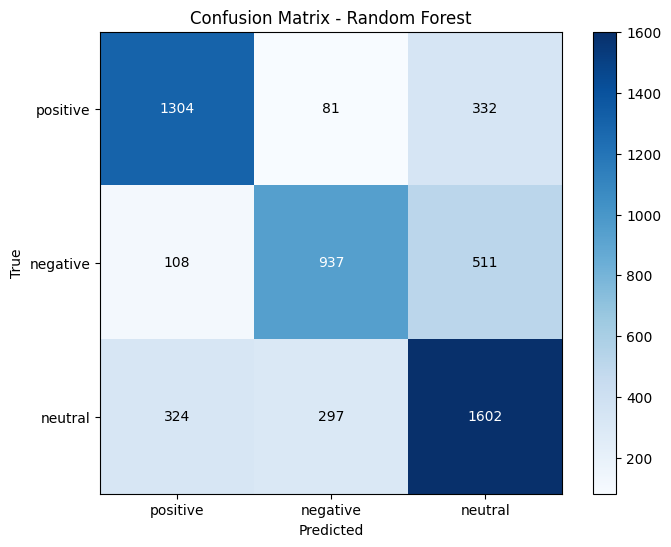

In [193]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.colorbar()
classes = ['positive', 'negative', 'neutral']
plt.xticks(range(3), classes)
plt.yticks(range(3), classes)
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(3):
    for j in range(3):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        plt.text(j, i, cm[i, j], ha='center', va='center', color=color)

Примеры предсказаний

In [195]:
label_to_text = {0: 'positive', 1: 'negative', 2: 'neutral'}

y_pred_best = best_model.predict(X_test_tfidf)
y_pred_proba = best_model.predict_proba(X_test_tfidf)

n_examples = 5
indices = np.random.choice(len(X_test), n_examples, replace=False)

for i, idx in enumerate(indices):
    text = X_test[idx]
    true_label = label_to_text[y_test[idx]]
    pred_label = label_to_text[y_pred_best[idx]]
    proba = y_pred_proba[idx]

    print(f"\nПример {i+1}:")
    print(f"Текст: {text}")
    print(f"True: {true_label}")
    print(f"Pred: {pred_label}")
    print(f"Вероятности: positive={proba[0]:.3f}, negative={proba[1]:.3f}, neutral={proba[2]:.3f}")


Пример 1:
Текст: seeing my friends and doing coursework i have the weekend off work so i am happy
True: positive
Pred: positive
Вероятности: positive=0.730, negative=0.080, neutral=0.190

Пример 2:
Текст: oh ouch that hurt washing machine is out to get me
True: negative
Pred: negative
Вероятности: positive=0.010, negative=0.870, neutral=0.120

Пример 3:
Текст: bummer macbook is bugging out any mac heads want to lend a helping hand
True: negative
Pred: negative
Вероятности: positive=0.130, negative=0.610, neutral=0.260

Пример 4:
Текст: what happened to the weather
True: neutral
Pred: neutral
Вероятности: positive=0.231, negative=0.042, neutral=0.727

Пример 5:
Текст: whos the one always working now oh yeah still me
True: neutral
Pred: neutral
Вероятности: positive=0.060, negative=0.280, neutral=0.660
